# Feature Engineering: Daily Time Series

This notebook transforms the cleaned trip-level data into a daily feature matrix ready for modelling in the fourth notebook.

Features built here:
- Lag features (1, 7, 14, 28 days)
- Rolling means and standard deviations (7, 14, 28 days)
- Cyclical sin/cos encoding for day-of-week, month, and day-of-year
- Binary weekend and Ontario holiday flags
- Aggregated daily statistics (mean duration, % annual members, etc.)

All feature logic lives in `src/timeseries.py` so every notebook works from
the same definitions.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "ridership_2023_clean.csv"
df = pd.read_csv(DATA_PATH)
print(f"{len(df):,} trips loaded")

5,344,361 trips loaded


### Build Daily Feature Matrix

We call the full pipeline from `src/timeseries`: aggregate, calendar features, lag features, rolling features. Rows with NaN from lag/rolling creation are dropped (we lose the first 28 days).

In [2]:
from src.timeseries import build_daily_features

daily = build_daily_features(df)
print(f"{len(daily)} days after dropping NaN rows")
print(f"Date range: {daily.index.min().date()} to {daily.index.max().date()}")
print(f"\nColumns ({len(daily.columns)}):")
print(daily.columns.tolist())
daily.head()

337 days after dropping NaN rows
Date range: 2023-01-29 to 2023-12-31

Columns (27):
['trip_count', 'mean_duration_min', 'median_duration_min', 'pct_annual_member', 'pct_peak_hour', 'pct_weekend', 'day_of_week', 'month', 'day_of_year', 'day_of_week_sin', 'day_of_week_cos', 'month_sin', 'month_cos', 'day_of_year_sin', 'day_of_year_cos', 'is_weekend', 'is_holiday', 'trip_count_lag1', 'trip_count_lag7', 'trip_count_lag14', 'trip_count_lag28', 'trip_count_rmean7', 'trip_count_rstd7', 'trip_count_rmean14', 'trip_count_rstd14', 'trip_count_rmean28', 'trip_count_rstd28']


,trip_count,mean_duration_min,median_duration_min,pct_annual_member,pct_peak_hour,pct_weekend,day_of_week,month,day_of_year,day_of_week_sin,...,trip_count_lag1,trip_count_lag7,trip_count_lag14,trip_count_lag28,trip_count_rmean7,trip_count_rstd7,trip_count_rmean14,trip_count_rstd14,trip_count_rmean28,trip_count_rstd28
date,,,,,,,,,,,,,,,,,,,,,
2023-01-29,3043,12.049189,9.866667,0.262570,0.465002,1.0,6,1,29,-0.781831,...,5066.0,3901.0,4569.0,3666.0,5135.714286,1699.516178,5838.642857,1634.202916,5710.464286,1574.995532
2023-01-30,5625,11.043185,9.216667,0.270400,0.593067,0.0,0,1,30,0.000000,...,3043.0,6643.0,6585.0,5457.0,5013.142857,1829.385091,5729.642857,1770.600533,5688.214286,1608.981328
2023-01-31,6048,11.147018,9.175000,0.287037,0.598876,0.0,1,1,31,0.781831,...,5625.0,8037.0,6054.0,5326.0,4867.714286,1715.118433,5661.071429,1753.432391,5694.214286,1608.400318
2023-02-01,5753,11.007419,9.250000,0.286459,0.605597,0.0,2,2,32,0.974928,...,6048.0,3342.0,8560.0,3467.0,4583.571429,1185.561029,5660.642857,1753.329694,5720.000000,1608.065988
2023-02-02,6091,11.164905,9.416667,0.284846,0.592349,0.0,3,2,33,0.433884,...,5753.0,3761.0,5551.0,6267.0,4928.000000,1112.727580,5460.142857,1544.309647,5801.642857,1546.287099


### Feature Overview

In [3]:
daily.describe().round(2)

,trip_count,mean_duration_min,median_duration_min,pct_annual_member,pct_peak_hour,pct_weekend,day_of_week,month,day_of_year,day_of_week_sin,...,trip_count_lag1,trip_count_lag7,trip_count_lag14,trip_count_lag28,trip_count_rmean7,trip_count_rstd7,trip_count_rmean14,trip_count_rstd14,trip_count_rmean28,trip_count_rstd28
count,337.00,337.00,337.00,337.00,337.00,337.00,337.00,337.00,337.00,337.00,...,337.00,337.00,337.00,337.00,337.00,337.00,337.00,337.00,337.00,337.00
mean,15384.18,12.36,10.65,0.09,0.55,0.29,3.01,6.99,197.00,-0.00,...,15385.01,15399.60,15388.84,15192.37,15386.13,2423.81,15395.97,2644.60,15346.34,2866.08
std,6969.70,0.98,1.04,0.10,0.07,0.45,2.01,3.19,97.43,0.71,...,6968.45,6948.13,6956.95,7157.10,6526.92,1023.57,6402.89,941.80,6352.26,874.47
min,1238.00,10.12,8.05,0.00,0.33,0.00,0.00,1.00,29.00,-0.97,...,1238.00,1238.00,1238.00,1238.00,3381.00,936.26,4677.79,1276.73,5471.82,1531.16
25%,9017.00,11.57,9.80,0.00,0.47,0.00,1.00,4.00,113.00,-0.78,...,9017.00,9017.00,9012.00,8170.00,9436.00,1695.46,9735.79,1911.90,9674.32,2217.22
50%,16445.00,12.30,10.57,0.02,0.58,0.00,3.00,7.00,197.00,0.00,...,16445.00,16445.00,16445.00,16445.00,16514.29,2162.80,17125.00,2432.73,16187.68,2697.63
75%,21710.00,12.93,11.22,0.20,0.61,1.00,5.00,10.00,281.00,0.78,...,21710.00,21710.00,21710.00,21710.00,21946.29,2825.38,21742.14,3171.15,21451.96,3550.87
max,25940.00,14.86,13.35,0.29,0.68,1.00,6.00,12.00,365.00,0.97,...,25940.00,25940.00,25940.00,25940.00,24486.14,7078.71,24223.93,5517.50,23789.29,4718.24


In [4]:
# Check for any remaining NaN
nan_counts = daily.isna().sum()
if nan_counts.sum() == 0:
    print("There are no missing values. The feature matrix is clean.")
else:
    print("Missing values:")
    print(nan_counts[nan_counts > 0])

There are no missing values. The feature matrix is clean.


### Visualize Cyclical Encodings

Cyclical sin/cos transforms ensure the model knows that Monday is close to Sunday, and December is close to January.

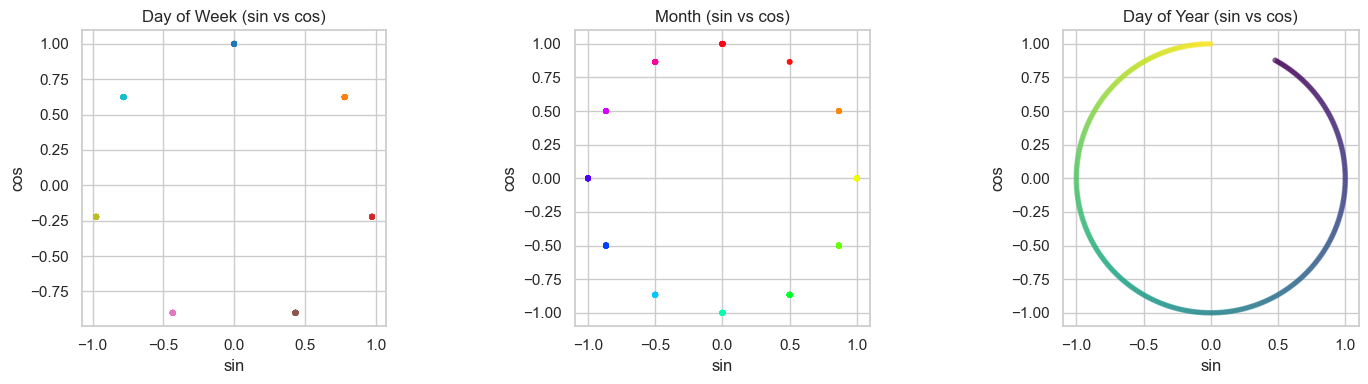

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Day of week
axes[0].scatter(daily['day_of_week_sin'], daily['day_of_week_cos'], c=daily['day_of_week'], cmap='tab10', alpha=0.5, s=10)
axes[0].set_title('Day of Week (sin vs cos)')
axes[0].set_xlabel('sin'); axes[0].set_ylabel('cos')
axes[0].set_aspect('equal')

# Month
axes[1].scatter(daily['month_sin'], daily['month_cos'], c=daily['month'], cmap='hsv', alpha=0.5, s=10)
axes[1].set_title('Month (sin vs cos)')
axes[1].set_xlabel('sin'); axes[1].set_ylabel('cos')
axes[1].set_aspect('equal')

# Day of year
axes[2].scatter(daily['day_of_year_sin'], daily['day_of_year_cos'], c=daily['day_of_year'], cmap='viridis', alpha=0.5, s=10)
axes[2].set_title('Day of Year (sin vs cos)')
axes[2].set_xlabel('sin'); axes[2].set_ylabel('cos')
axes[2].set_aspect('equal')

plt.tight_layout()
plt.show()

### Lag Feature Correlations

How well do past trip counts predict today's count?

Correlation of lag/rolling features with trip_count:

trip_count_lag1       0.9063
trip_count_rmean7     0.9030
trip_count_rmean14    0.8904
trip_count_rmean28    0.8703
trip_count_lag7       0.8413
trip_count_lag14      0.8109
trip_count_lag28      0.7532
Name: trip_count, dtype: float64


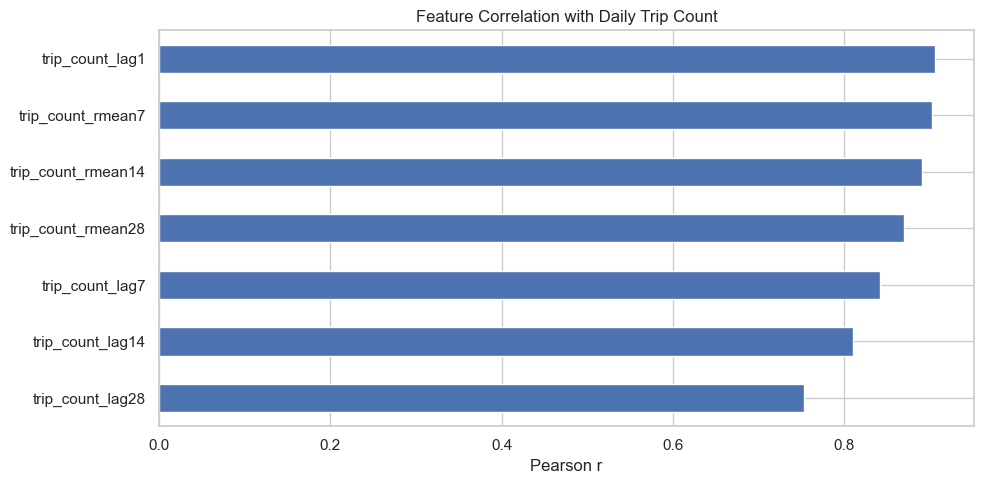

In [6]:
lag_cols = [c for c in daily.columns if 'lag' in c or 'rmean' in c]
corr_with_target = daily[lag_cols + ['trip_count']].corr()['trip_count'].drop('trip_count').sort_values(ascending=False)

print("Correlation of lag/rolling features with trip_count:\n")
print(corr_with_target.round(4))

fig, ax = plt.subplots(figsize=(10, 5))
corr_with_target.plot(kind='barh', ax=ax)
ax.set_title('Feature Correlation with Daily Trip Count')
ax.set_xlabel('Pearson r')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### Full Feature Correlation Heatmap

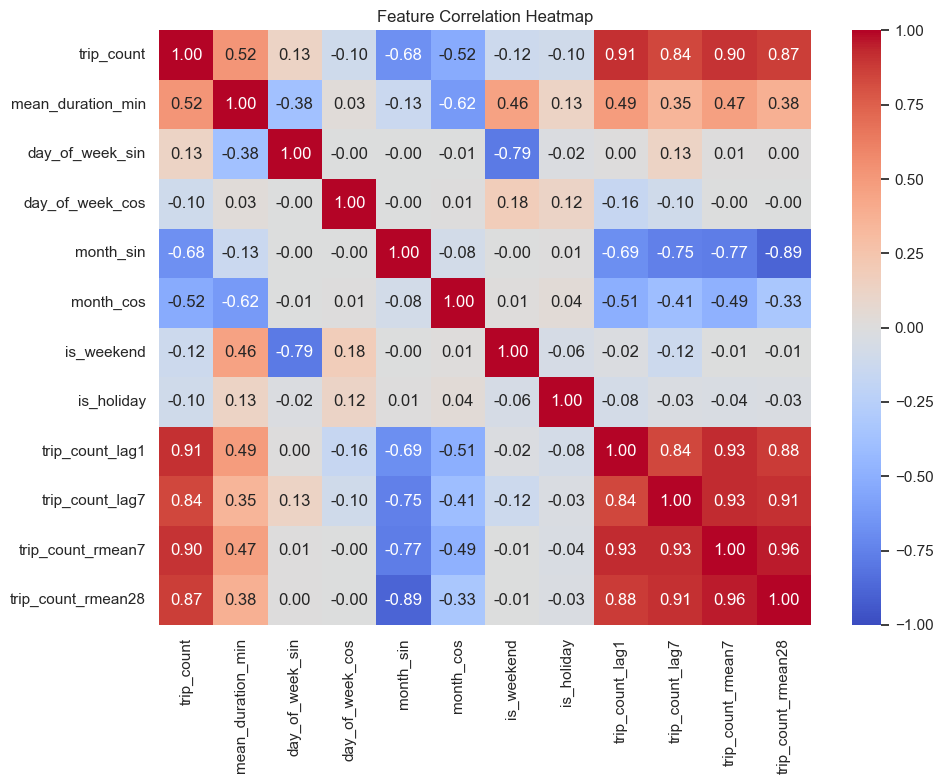

In [7]:
# Select a subset of key features to keep the heatmap readable
key_features = [
    'trip_count',
    'mean_duration_min',
    'day_of_week_sin',
    'day_of_week_cos',
    'month_sin',
    'month_cos',
    'is_weekend',
    'is_holiday',
    'trip_count_lag1',
    'trip_count_lag7',
    'trip_count_rmean7',
    'trip_count_rmean28'
]
key_features = [c for c in key_features if c in daily.columns]

corr = daily[key_features].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', ax=ax, vmin=-1, vmax=1)
ax.set_title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

### Train/Test Split Preview

For time series, we use a temporal split: train on earlier data, test on the final portion. We hold out the last 60 days (Nov to Dec) for evaluation.

Train: 277 days (2023-01-29 to 2023-11-01)
Test: 60 days (2023-11-02 to 2023-12-31)


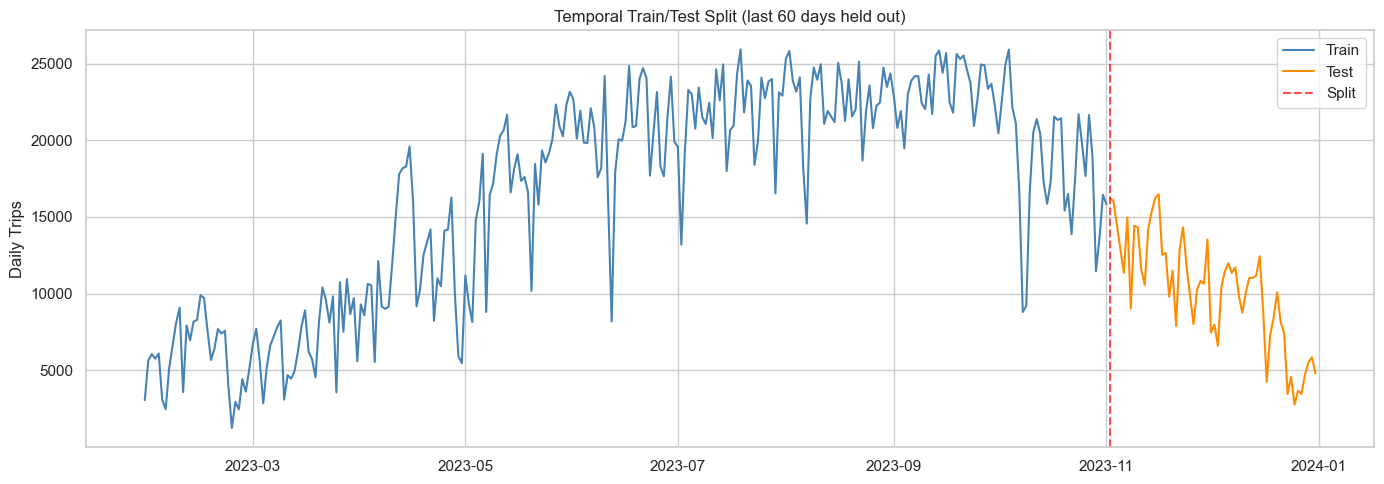

In [8]:
TEST_DAYS = 60
split_date = daily.index[-TEST_DAYS]

train = daily[daily.index < split_date]
test = daily[daily.index >= split_date]

print(f"Train: {len(train)} days ({train.index.min().date()} to {train.index.max().date()})")
print(f"Test: {len(test)} days ({test.index.min().date()} to {test.index.max().date()})")

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train.index, train['trip_count'], label='Train', color='steelblue')
ax.plot(test.index, test['trip_count'], label='Test', color='darkorange')
ax.axvline(split_date, color='red', linestyle='--', alpha=0.7, label='Split')
ax.set_title(f'Temporal Train/Test Split (last {TEST_DAYS} days held out)')
ax.set_ylabel('Daily Trips')
ax.legend()
plt.tight_layout()
plt.show()

### Export Feature Matrix

In [9]:
output_path = PROJECT_ROOT / "data" / "processed" / "daily_features.csv"
daily.to_csv(output_path)
print(f"Saved {len(daily)} rows x {len(daily.columns)} columns to {output_path.name}")

Saved 337 rows x 27 columns to daily_features.csv
